# 6 — Getting started with the case studies

This notebook is the **preparation kit** for the two case studies you will solve
in groups. It does *not* solve them — it wires up the building blocks from the
**GAA repository** so you can spend your time on the analysis, not the plumbing.

| Case | Frequency | What you build here |
|------|-----------|--------------------|
| **Yale Investments Office** | **quarterly** | Decade-average allocations, backtest, illiquid-asset *unsmoothing*, an ACWI/Agg benchmark, and scenario-tilted expected returns. |
| **UBS Risk Parity** | monthly | Four risk *clusters*, a covariance estimate, an equal-risk-contribution portfolio, and volatility targeting via leverage. |

Cells marked **:pencil2: Your turn** are deliberately incomplete — that is the part you finish.

Unlike the Colab notebook, everything below runs **locally against the GAA
framework** (`optimization/`, `backtesting/`, `analytics/`, `risk_models/`,
`data/`) and the parquet data in `the repo root`. The **illiquid** Yale
series (private equity, real estate) are taken at their native **quarterly**
frequency, where appraisal smoothing is visible; the remaining buckets are
resampled from monthly to quarterly.

In [1]:
# --- Make the GAA package importable and locate the data ---------------
import sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "optimization").is_dir()), pathlib.Path.cwd())
sys.path.insert(0, str(REPO))

DATA_DIR = REPO

from analytics.timeseries_analyzer import TimeseriesAnalyzer
from backtesting import BacktestConfig, Backtester
from data.generate_data import unsmooth_Geltner
from optimization import (
    MaxUtility, MeanRiskOptimizer, RiskBudgetOptimizer, Variance, WeightBounds,
)
from risk_models.covariance import compute_covariance

pd.set_option("display.float_format", "{:.4f}".format)
print("repo:", REPO)

repo: C:\Users\jakub\gaa_students


In [2]:
# Performance panels: columns are "{ASSET}-r" (return) and "{ASSET}-i" (price)
perf  = pd.read_parquet(DATA_DIR / "perf_M.parquet")   # monthly
perfQ = pd.read_parquet(DATA_DIR / "perf_Q.parquet")   # quarterly (illiquid series)

def ret(asset: str) -> pd.Series:
    """Monthly simple-return series for an asset ticker (used by the UBS case)."""
    return perf[f"{asset}-r"]

def blend(weights: dict[str, float]) -> pd.Series:
    """Fixed-weight blend of several assets' monthly return series."""
    return sum(w * ret(a) for a, w in weights.items())

def q_ret(asset: str, native: bool = False) -> pd.Series:
    """Quarterly return series (used by the Yale case).

    native=True  -> read the asset's own series from the quarterly panel
                    (illiquid / appraisal-based: PE, RE).
    native=False -> resample the monthly price index to quarter-end and
                    take the percentage change.
    """
    if native:
        return perfQ[f"{asset}-r"]
    return perf[f"{asset}-i"].resample("QE").last().pct_change()

print(perf.shape, "monthly |", perfQ.shape, "quarterly")

(792, 78) monthly | (264, 4) quarterly


---
# Part A — Yale Investments Office *(quarterly)*

## A.1  Map the Yale asset classes to GAA proxies

The case reports allocations in broad buckets (Exhibit 1). The GAA universe has
no private Yale series, so we approximate each bucket with **public proxies** —
a modelling choice to interrogate. The two **illiquid** buckets are taken from
the **quarterly** panel (`perfQ`) at their native frequency; the liquid buckets
are resampled from monthly.

| Yale bucket | GAA proxy (equal-weight blend unless noted) | Source |
|---|---|---|
| Domestic Equity | `EQ_US` | M→Q |
| Foreign Equity | 0.7·`EQ_EA` (developed ex-US) + 0.3·`EQ_EM` | M→Q |
| Cash & Bonds | `FI_GB_US` (US government bonds) | M→Q |
| Real Assets | 0.5·`RE` (direct real estate) + 0.25·`CO` + 0.25·`CO_GO` | **RE: Q** |
| Private Equity | `PE_LPX` (listed private-equity index) | **Q** |
| Absolute Return | `HFRI` (hedge-fund composite) | M→Q |

In [3]:
# (asset, weight, native_quarterly?) per bucket
yale_components = {
    "DomesticEquity": [("EQ_US", 1.0, False)],
    "ForeignEquity":  [("EQ_EA", 0.7, False), ("EQ_EM", 0.3, False)],
    "CashBonds":      [("FI_GB_US", 1.0, False)],
    "RealAssets":     [("RE", 0.5, True), ("CO", 0.25, False), ("CO_GO", 0.25, False)],
    "PrivateEquity":  [("PE_LPX", 1.0, True)],
    "AbsoluteReturn": [("HFRI", 1.0, False)],
}
bucket_rets = pd.DataFrame(
    {b: sum(w * q_ret(a, nat) for a, w, nat in comps)
     for b, comps in yale_components.items()}
).dropna()
PPY = 4   # periods per year (quarterly)
print("common sample:", bucket_rets.index.min().date(), "->",
      bucket_rets.index.max().date(),
      f"({len(bucket_rets)} quarters, freq {bucket_rets.index.inferred_freq})")
bucket_rets.head()

common sample: 1994-03-31 -> 2025-12-31 (128 quarters, freq QE-DEC)


,DomesticEquity,ForeignEquity,CashBonds,RealAssets,PrivateEquity,AbsoluteReturn
1994-03-31,-0.0429,-0.0059,-0.0302,0.0146,0.0634,0.0040
1994-06-30,-0.0047,0.0270,-0.0113,0.0299,-0.0104,0.0036
1994-09-30,0.0449,0.0596,0.0042,0.0112,0.0114,0.0477
1994-12-31,-0.0040,-0.0538,0.0035,0.0090,0.0062,-0.0138
1995-03-31,0.0958,-0.0246,0.0468,0.0218,-0.0292,0.0276


## A.2  Decade-average target allocations

Read off Exhibit 1 and average within each decade. The numbers below are
**rough** — the case asks you to do this carefully (and to decide how to fold
the 2012 Real-Assets split and the 2016 PE→LBO+VC split into the six buckets).

In [4]:
# Approximate decade-average allocations (percent). REFINE these from Exhibit 1.
decade_alloc = pd.DataFrame({
    "1980s": [59, 11, 17,  9,  4,  0],
    "1990s": [27, 14, 16, 12, 14, 17],
    "2000s": [11, 13,  6, 22, 24, 24],
    "2010s": [ 4, 13,  6, 17, 38, 22],
}, index=list(yale_components)).astype(float)
decade_alloc = decade_alloc / decade_alloc.sum()   # normalise each column to 1
decade_alloc.style.format("{:.1%}")

,1980s,1990s,2000s,2010s
DomesticEquity,59.0%,27.0%,11.0%,4.0%
ForeignEquity,11.0%,14.0%,13.0%,13.0%
CashBonds,17.0%,16.0%,6.0%,6.0%
RealAssets,9.0%,12.0%,22.0%,17.0%
PrivateEquity,4.0%,14.0%,24.0%,38.0%
AbsoluteReturn,0.0%,17.0%,24.0%,22.0%


## A.3  Backtest each decade allocation  *(Question 1, part 1)*

We turn each bucket into a quarterly price index, then run the framework
`Backtester` with **constant weights** and annual rebalancing. `TimeseriesAnalyzer`
infers the quarterly frequency and annualises automatically, so the four
allocation *styles* are compared on the same market history.

                                  1980s   1990s   2000s   2010s
calc_cagr                        0.0959  0.0894  0.0900  0.0920
calc_volatility                  0.1221  0.1147  0.1258  0.1528
calc_sharpe_ratio                0.8191  0.8112  0.7547  0.6569
calc_max_drawdown__max_drawdown -0.3553 -0.3458 -0.3909 -0.4661


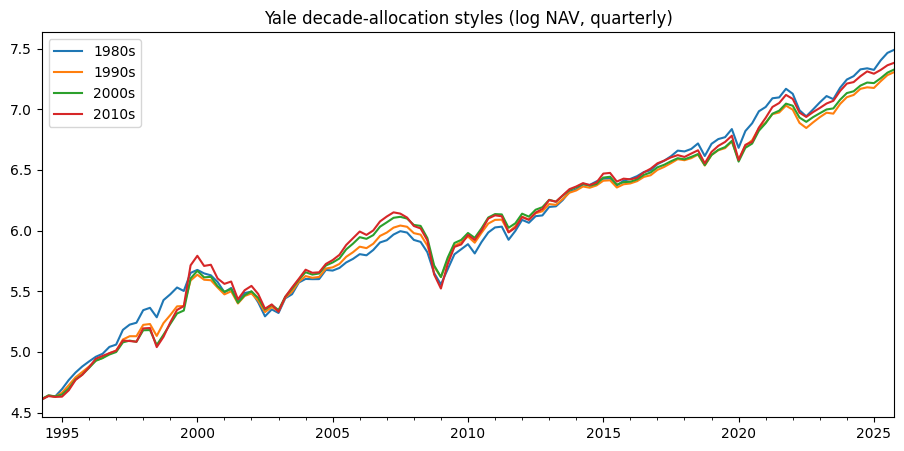

In [5]:
# Quarterly bucket price indices (base 100) for the backtester
prices = (1 + bucket_rets).cumprod() * 100
prices.columns = [f"{c}-i" for c in prices.columns]

class ConstantWeights:
    """A Strategy that always returns the same target weights."""
    def __init__(self, weights: pd.Series) -> None:
        self.weights = weights
    def compute_weights(self, data, as_of, current_weights) -> pd.Series:
        return self.weights

config = BacktestConfig(initial_capital=100.0, rebalance_freq="YE",
                        transaction_cost_bps=5, initial_weights_from_strategy=True)
bt = Backtester(config)

navs = {}
for dec in decade_alloc.columns:
    w = pd.Series(decade_alloc[dec].values, index=prices.columns)
    navs[dec] = bt.run(prices, ConstantWeights(w)).nav

nav_df = pd.DataFrame(navs)
metrics = TimeseriesAnalyzer(nav_df).apply_standard_functions()
rows = ["calc_cagr", "calc_volatility", "calc_sharpe_ratio",
        "calc_max_drawdown__max_drawdown"]
print(metrics.loc[rows])
np.log(nav_df).plot(figsize=(11, 5), title="Yale decade-allocation styles (log NAV, quarterly)")
plt.show()

**Read the table.** Which decade's *style* delivered the best CAGR? The best
Sharpe? Note these are on **reported (smoothed) returns** for the illiquid
buckets — which flatters their volatility. We fix that next.

## A.4  Unsmooth the illiquid assets  *(Question 1, part 2)*

Appraisal-based / private series are **autocorrelated**: reported returns are a
moving average of true returns, so volatility is understated — and this is far
clearer at **quarterly** frequency. We invert a first-order appraisal filter
(Geltner 1994): with AR(1) coefficient $\rho$,
$$ r^{\text{true}}_t = \frac{r^{\text{obs}}_t - \rho\, r^{\text{obs}}_{t-1}}{1-\rho}. $$
`data.generate_data.unsmooth_Geltner` estimates $\rho$ and returns the unsmoothed series.

In [6]:
unsmoothed = bucket_rets.copy()
for b in ["RealAssets", "PrivateEquity"]:
    u, rho = unsmooth_Geltner(bucket_rets[b])
    unsmoothed[b] = u
    print(f"{b:14s} AR(1) rho={rho:5.3f} | vol {bucket_rets[b].std()*np.sqrt(PPY):6.2%}"
          f"  ->  unsmoothed {u.std()*np.sqrt(PPY):6.2%}")

unsmoothed = unsmoothed.dropna()
# Re-run the backtest on unsmoothed bucket returns and compare risk-adjusted stats
prices_u = (1 + unsmoothed).cumprod() * 100
prices_u.columns = [f"{c}-i" for c in prices_u.columns]
navs_u = {dec: bt.run(prices_u, ConstantWeights(
              pd.Series(decade_alloc[dec].values, index=prices_u.columns))).nav
          for dec in decade_alloc.columns}
metrics_u = TimeseriesAnalyzer(pd.DataFrame(navs_u)).apply_standard_functions()
compare = pd.concat({"smoothed": metrics.loc[rows], "unsmoothed": metrics_u.loc[rows]},
                    axis=1)
print()
print(compare)

RealAssets     AR(1) rho=0.440 | vol  6.87%  ->  unsmoothed 11.93%
PrivateEquity  AR(1) rho=0.180 | vol 28.74%  ->  unsmoothed 34.90%



                                smoothed                         unsmoothed  \
                                   1980s   1990s   2000s   2010s      1980s   
calc_cagr                         0.0959  0.0894  0.0900  0.0920     0.0946   
calc_volatility                   0.1221  0.1147  0.1258  0.1528     0.1260   
calc_sharpe_ratio                 0.8191  0.8112  0.7547  0.6569     0.7887   
calc_max_drawdown__max_drawdown  -0.3553 -0.3458 -0.3909 -0.4661    -0.3648   

                                                         
                                  1990s   2000s   2010s  
calc_cagr                        0.0870  0.0858  0.0859  
calc_volatility                  0.1244  0.1429  0.1769  
calc_sharpe_ratio                0.7393  0.6525  0.5571  
calc_max_drawdown__max_drawdown -0.3602 -0.4177 -0.4922  


:pencil2: **Your turn.** The direct-real-estate proxy (`RE`) is strongly
appraisal-smoothed at quarterly frequency; the listed-PE proxy far less so.
Decide which buckets truly need unsmoothing, try capping $\rho$ with
`unsmooth_Geltner(s, max_beta=...)`, and re-rank the decades on the
**unsmoothed** Sharpe. Does the ranking change?

## A.5  An ACWI / Global-Agg benchmark  *(Question 1, part 3)*

A defensible benchmark for each decade allocation is a single
**stock/bond split** with the same risk. ACWI ≈ `EQ_WL`, Global-Agg ≈
`FI_IG_ALL` (both resampled to quarterly). The helper finds the equity weight
whose volatility matches a target.

In [7]:
bench_rets = pd.DataFrame({"ACWI": q_ret("EQ_WL"), "Agg": q_ret("FI_IG_ALL")}).dropna()

def equity_weight_matching_vol(target_vol_ann: float) -> float:
    """Equity share x in x*ACWI+(1-x)*Agg whose annualised vol ~ target."""
    grid = np.linspace(0, 1, 101)
    vols = [( (x*bench_rets["ACWI"] + (1-x)*bench_rets["Agg"]).std()*np.sqrt(PPY) )
            for x in grid]
    return float(grid[int(np.argmin(np.abs(np.array(vols) - target_vol_ann)))])

# Example: match the 2000s allocation's (smoothed) volatility
tgt = metrics.loc["calc_volatility", "2000s"]
x = equity_weight_matching_vol(tgt)
print(f"2000s vol={tgt:.2%}  ->  benchmark = {x:.0%} ACWI / {1-x:.0%} Agg")

2000s vol=12.58%  ->  benchmark = 77% ACWI / 23% Agg


:pencil2: **Your turn.** Build the matching ACWI/Agg benchmark for *each* decade
allocation, backtest it on the common window, and report the Yale-style
allocation's excess return and information ratio versus its benchmark.

## A.6  Scenario-tilted expected returns  *(Question 2)*

Exhibit 7 sketches four COVID scenarios. Encode each as an **additive shift** to
expected returns (and, optionally, a scaling of the covariance), then form the
**probability-weighted** inputs and re-optimise. Yale caps each asset class — we
mirror that with `WeightBounds`, so the optimiser cannot short or over-concentrate.
All inputs are annualised from the quarterly returns ($\times 4$).

In [8]:
mu_base = bucket_rets.mean() * PPY * 100         # annualised expected returns (pp)
cov_ann = compute_covariance(bucket_rets, "sample") * PPY   # annualised covariance

# Scenario shifts to mu (percentage points) — EDIT to match your reading of Exhibit 7
idx = mu_base.index
scenarios = {
    "base":       pd.Series([ 0,  0,  0,  0,  0,  0], index=idx, dtype=float),
    "depression": pd.Series([-6, -6,  2, -4, -8, -3], index=idx, dtype=float),
    "inflation":  pd.Series([-1, -1, -2,  4, -2,  1], index=idx, dtype=float),
    "optimistic": pd.Series([ 3,  3,  0,  2,  5,  2], index=idx, dtype=float),
}
probs = {"base": 0.50, "depression": 0.20, "inflation": 0.15, "optimistic": 0.15}

mu_mix = mu_base + sum(probs[s] * scenarios[s] for s in scenarios)
mvo = MeanRiskOptimizer(solver="scipy")
caps = [WeightBounds(lower=0.0, upper=0.30)]      # Yale-style per-bucket ceiling
w = mvo.optimize(mu_mix, cov_ann, MaxUtility(Variance(), risk_aversion=8.0),
                 constraints=caps)
print("probability-weighted expected returns (pp):"); print(mu_mix.round(2))
print("\\noptimal allocation:"); print(w.round(3))

probability-weighted expected returns (pp):
DomesticEquity   10.8300
ForeignEquity     6.9800
CashBonds         4.1700
RealAssets        7.1800
PrivateEquity    12.1300
AbsoluteReturn    7.5900
dtype: float64
\noptimal allocation:
DomesticEquity   0.1910
ForeignEquity    0.0000
CashBonds        0.2420
RealAssets       0.3000
PrivateEquity    0.0000
AbsoluteReturn   0.2670
Name: weights, dtype: float64


In [9]:
# How the allocation tilts as we lean into one scenario (prob -> 0.6 on it)
def allocation_for(probs: dict) -> pd.Series:
    m = mu_base + sum(probs[s] * scenarios[s] for s in scenarios)
    return mvo.optimize(m, cov_ann, MaxUtility(Variance(), risk_aversion=8.0),
                        constraints=caps)

tilts = {}
for lead in scenarios:
    p = {s: (0.6 if s == lead else 0.4/3) for s in scenarios}
    tilts[f"lean {lead}"] = allocation_for(p)
pd.DataFrame(tilts).round(3)

,lean base,lean depression,lean inflation,lean optimistic
DomesticEquity,0.2050,0.1000,0.2080,0.2410
ForeignEquity,0.0000,0.0000,0.0000,0.0000
CashBonds,0.2220,0.3000,0.1920,0.1590
RealAssets,0.3000,0.3000,0.3000,0.3000
PrivateEquity,0.0000,0.0000,0.0000,0.0000
AbsoluteReturn,0.2720,0.3000,0.3000,0.3000


:pencil2: **Your turn.** (a) Should the *covariance* also change by scenario — e.g.
scale `cov_ann` up in the depression case, raise equity–credit correlation in a
crisis? Implement a per-scenario covariance and average it. (b) Re-run with your
own probabilities and Exhibit-7 numbers and describe how the allocation moves.

## A.7  Discussion prompts *(Questions 3 & 4 — no code)*

- **Q3 — the 50% illiquidity ceiling.** How does capping illiquid assets at 50%
  limit Yale's ability to out-manoeuvre peers? Think about: forced sellers in a
  crisis vs. dry powder to *buy* secondaries; the return give-up Swensen accepts
  for liquidity; and why "liquidity doesn't show up in a mean-variance model."
- **Q4 — principles vs. recipe.** When does *creating principles* (not *following
  a recipe*) generate outperformance? Relate to first-mover manager access,
  incentive alignment, and the difficulty of copying a culture.

---
# Part B — UBS Risk Parity *(monthly)*

## B.1  Build the four risk clusters

Mirror Figure 9 of the concept paper with GAA proxies. Intra-cluster weights are
fixed; risk parity then balances *across* clusters.

| Cluster | GAA proxy |
|---|---|
| Equity | `EQ_WL` |
| Bond | `FI_GB_US` |
| Credit | `FI_HY_US` |
| Inflation | 0.4·`FI_IL` + 0.3·`CO` + 0.3·`CO_GO` |

In [10]:
clusters = {
    "Equity":    {"EQ_WL": 1.0},
    "Bond":      {"FI_GB_US": 1.0},
    "Credit":    {"FI_HY_US": 1.0},
    "Inflation": {"FI_IL": 0.4, "CO": 0.3, "CO_GO": 0.3},
}
cl_rets = pd.DataFrame({c: blend(w) for c, w in clusters.items()}).dropna()
print("sample:", cl_rets.index.min().date(), "->", cl_rets.index.max().date())
(cl_rets.std() * np.sqrt(12)).rename("annualised vol").to_frame()

sample: 1997-11-30 -> 2025-12-31


,annualised vol
Equity,0.1539
Bond,0.0461
Credit,0.0875
Inflation,0.0876


## B.2  Risk contributions and the risk-parity portfolio  *(interview Q on risk contributions)*

Euler's theorem splits portfolio volatility into additive contributions
$\mathrm{RC}_i = w_i (\Sigma w)_i / \sqrt{w^\top\Sigma w}$. Risk parity chooses
weights so every $\mathrm{RC}_i$ is equal. We show **two** routes: a from-scratch
objective (the "build your own model" ask) and the repo's `RiskBudgetOptimizer`
(Spinu log-barrier).

In [11]:
from scipy.optimize import minimize

def risk_parity_objective(weights, cov):
    """L2 distance of relative risk contributions from equal (1/N)."""
    w = np.asarray(weights)
    port_vol = np.sqrt(w @ cov @ w)
    rc = w * (cov @ w) / port_vol
    rel = rc / rc.sum()
    return np.sum((rel - 1/len(w))**2)

cov_ubs = compute_covariance(cl_rets, "ewma", halflife=24) * 12   # annualised
S = cov_ubs.values
n = S.shape[0]
res = minimize(risk_parity_objective, np.ones(n)/n, args=(S,), method="SLSQP",
               constraints={"type": "eq", "fun": lambda w: w.sum() - 1},
               bounds=[(0, 1)]*n)
w_diy = pd.Series(res.x, index=cl_rets.columns)

# Same thing via the framework optimiser
w_rp = RiskBudgetOptimizer(solver="scipy").optimize(cov_ubs)
rc = RiskBudgetOptimizer.risk_contributions(w_rp, cov_ubs)
pd.DataFrame({"DIY weight": w_diy, "RiskBudget weight": w_rp, "risk %": rc}).round(4)

,DIY weight,RiskBudget weight,risk %
Equity,0.1210,0.1209,0.2500
Bond,0.3886,0.3887,0.2500
Credit,0.2472,0.2472,0.2500
Inflation,0.2433,0.2433,0.2500


## B.3  Estimating the covariance  *(interview Q on the covariance)*

The paper estimates volatilities on a rolling **1-year daily** window and
correlations on a rolling **2-year weekly** window. Here we compare a plain
**sample** estimate with an **EWMA** (recent observations weighted more).

In [12]:
cov_sample = compute_covariance(cl_rets, "sample") * 12
cov_ewma   = compute_covariance(cl_rets, "ewma", halflife=24) * 12
comp = pd.DataFrame({
    "sample vol":  np.sqrt(np.diag(cov_sample)),
    "EWMA vol":    np.sqrt(np.diag(cov_ewma)),
}, index=cl_rets.columns)
print(comp.round(4))
print("\\nEWMA correlation:")
d = np.sqrt(np.diag(cov_ewma))
print((cov_ewma / np.outer(d, d)).round(2))

           sample vol  EWMA vol
Equity         0.1539    0.1443
Bond           0.0461    0.0511
Credit         0.0875    0.0676
Inflation      0.0876    0.0783
\nEWMA correlation:
           Equity   Bond  Credit  Inflation
Equity     1.0000 0.4100  0.8600     0.4900
Bond       0.4100 1.0000  0.4700     0.4400
Credit     0.8600 0.4700  1.0000     0.5300
Inflation  0.4900 0.4400  0.5300     1.0000


## B.4  Volatility targeting via leverage

The unlevered risk-parity portfolio has a low volatility; UBS levers it to a
target. Leverage = target / current portfolio volatility (Figure 13 reports
~4% unlevered, so an 8% target ≈ 2×).

In [13]:
port_vol = float(np.sqrt(w_rp.values @ cov_ubs.values @ w_rp.values))
for target in [0.04, 0.06, 0.08, 0.10]:
    lev = target / port_vol
    print(f"target {target:.0%}: leverage {lev:4.2f}x  ->  cluster exposures "
          + ", ".join(f"{c} {lev*w_rp[c]:.0%}" for c in w_rp.index))

target 4%: leverage 0.68x  ->  cluster exposures Equity 8%, Bond 27%, Credit 17%, Inflation 17%
target 6%: leverage 1.02x  ->  cluster exposures Equity 12%, Bond 40%, Credit 25%, Inflation 25%
target 8%: leverage 1.37x  ->  cluster exposures Equity 16%, Bond 53%, Credit 34%, Inflation 33%
target 10%: leverage 1.71x  ->  cluster exposures Equity 21%, Bond 66%, Credit 42%, Inflation 42%


## B.5  Exposure and performance in 2018 & 2019  *(interview Q)*

Risk parity is rebalanced as the covariance moves. We compute the risk-parity
weights from the EWMA covariance **as of each year-end**, lever to an 8% target,
and report the exposures the strategy would have carried into 2018 and 2019 —
plus a monthly-rebalanced backtest to read off the realised returns.

In [14]:
TARGET_VOL = 0.08

def rp_exposure_asof(asof: pd.Timestamp) -> pd.Series:
    cov = compute_covariance(cl_rets.loc[:asof], "ewma", halflife=24) * 12
    w = RiskBudgetOptimizer(solver="scipy").optimize(cov)
    lev = TARGET_VOL / float(np.sqrt(w.values @ cov.values @ w.values))
    return (lev * w).rename(asof.year + 1)

exp = pd.DataFrame({2018: rp_exposure_asof(pd.Timestamp("2017-12-31")),
                    2019: rp_exposure_asof(pd.Timestamp("2018-12-31"))})
print("Levered cluster exposures entering each year (8% vol target):")
print(exp.round(3))

Levered cluster exposures entering each year (8% vol target):


            2018   2019
Equity    0.2770 0.2770
Bond      1.1580 1.2480
Credit    0.3980 0.4670
Inflation 0.3310 0.4010


In [15]:
# Monthly-rebalanced risk-parity backtest, levered to 8% vol, vs a 60/40 portfolio
cl_prices = (1 + cl_rets).cumprod() * 100
cl_prices.columns = [f"{c}-i" for c in cl_prices.columns]

class RiskParityStrategy:
    """Recompute levered risk-parity weights from trailing EWMA covariance."""
    def __init__(self, returns, target_vol=TARGET_VOL):
        self.returns, self.target_vol = returns, target_vol
        self.opt = RiskBudgetOptimizer(solver="scipy")
    def compute_weights(self, data, as_of, current_weights):
        cov = compute_covariance(self.returns.loc[:as_of], "ewma", halflife=24) * 12
        w = self.opt.optimize(cov)
        lev = self.target_vol / float(np.sqrt(w.values @ cov.values @ w.values))
        return pd.Series((lev * w).values, index=cl_prices.columns)

class SixtyForty:
    def compute_weights(self, data, as_of, current_weights):
        return pd.Series([0.6, 0.4, 0.0, 0.0], index=cl_prices.columns)  # Equity/Bond

# Burn-in: let the covariance settle before the first rebalance (a 1-month
# EWMA covariance is ~0 and would imply absurd leverage).
burn_in = cl_prices.index[0] + pd.DateOffset(years=5)
cl_prices_bt = cl_prices.loc[burn_in:]

bt_ubs = Backtester(BacktestConfig(rebalance_freq="ME", transaction_cost_bps=5,
                                   initial_weights_from_strategy=True))
nav_rp = bt_ubs.run(cl_prices_bt, RiskParityStrategy(cl_rets)).nav
nav_64 = bt_ubs.run(cl_prices_bt, SixtyForty()).nav
nav_cmp = pd.DataFrame({"Risk parity (8% vol)": nav_rp, "60/40": nav_64})

for yr in [2018, 2019]:
    sub = nav_cmp.loc[str(yr)]
    print(f"{yr} return:  " + "  ".join(
        f"{c} {sub[c].iloc[-1]/sub[c].iloc[0]-1:+.2%}" for c in nav_cmp.columns))
print()
print(TimeseriesAnalyzer(nav_cmp).apply_standard_functions().loc[
    ["calc_cagr", "calc_volatility", "calc_sharpe_ratio",
     "calc_max_drawdown__max_drawdown"]])

2018 return:  Risk parity (8% vol) -3.94%  60/40 -6.88%
2019 return:  Risk parity (8% vol) +20.67%  60/40 +14.07%

                                Risk parity (8% vol)   60/40
calc_cagr                                     0.0841  0.0759
calc_volatility                               0.0858  0.0905
calc_sharpe_ratio                             0.9873  0.8561
calc_max_drawdown__max_drawdown              -0.2555 -0.3276


:pencil2: **Your turn.** The exposures above use a single EWMA window for both
vol and correlation. Reproduce the paper's split estimator (1-yr daily vol, 2-yr
weekly correlation), add a momentum/trend overlay on the equity and inflation
clusters, and re-examine the 2018–2019 exposures and drawdowns.

## B.6  Discussion prompts *(no code)*

- **RP vs. a balanced 60/40:** advantages (diversified *risk*, no expected-return
  forecast needed, more stable realised vol) vs. drawbacks (leverage and its
  funding/liquidity risk, large nominal bond exposure, reliance on the
  vol/correlation estimate).
- **Biggest room for improvement** in *your* model: covariance estimation, the
  trend/momentum overlay, cluster design, turnover/cost control, leverage caps.

---
### Deliverables checklist
- **Yale:** decade rankings on smoothed *and* unsmoothed returns; matched ACWI/Agg
  benchmarks; scenario-tilted allocations under your own probabilities; written
  answers to Q3–Q4.
- **UBS:** your risk-parity model (this notebook is a starting point); 2018/2019
  exposures and performance; covariance method; RP-vs-balanced discussion; R&D ideas.